# MeteoSaver v1.0 – Minimal Working Example (MWE)

### A Jupyter Notebook to demonstrate the setup and use of MeteoSaver on sample data.

This notebook guides you through setting up and running **MeteoSaver v1.0** on a sample dataset.  
We will:
- Clone the repository  
- Set up the environment  
- Run the transcription  
- View results  

⚠️ **Note:** Run each cell **sequentially** or execute the entire notebook.

Note: You can run each of these cells individually or run the entire notebook

## Step 1: Clone the Repository

In [2]:
# Step 1: Clone the repository
!git clone https://github.com/VUB-HYDR/MeteoSaver.git MeteoSaver_Clone

Cloning into 'MeteoSaver_Clone'...


In [9]:
from pathlib import Path
import os, sys

# Step 1: Clone if needed
repo_name = "MeteoSaver_Clone"
repo_path = Path.cwd() / repo_name

if not repo_path.exists():
    !git clone https://github.com/VUB-HYDR/MeteoSaver.git {repo_name}


## Step 2: Navigate to the Project Directory

In [10]:
import os, subprocess, sys
from pathlib import Path

# Step 1: go to repo
os.chdir(repo_name)  # <-- match your folder name

print(os.listdir())

['.git', '.gitignore', '.vscode', 'configuration.ini', 'data', 'Dockerfile', 'docs', 'environment.yml', 'job_script.sh', 'LICENSE', 'manual_and_minimal_working_example', 'meteosaver_virtual_environment', 'OCR_HTR_models', 'README.md', 'requirements.in', 'results', 'setup.py', 'src']


## Step 3: Set Up the Python Environment
 
⚠️ This might take sometime to install all the required packages. Also note that, in our software development we used Python 3.9

In [15]:
venv_dir = Path.cwd() / "meteosaver_virtual_environment"

if not venv_dir.exists():
    subprocess.check_call([sys.executable, "-m", "venv", str(venv_dir)])

venv_py = venv_dir / ("Scripts" if os.name == "nt" else "bin") / ("python.exe" if os.name == "nt" else "python")

# install pip + kernel
subprocess.check_call([str(venv_py), "-m", "pip", "install", "--upgrade", "pip", "ipykernel"])

# install requirements in venv
subprocess.check_call([str(venv_py), "-m", "pip", "install", "-r", "requirements.in"])

# register kernel
subprocess.check_call([
    str(venv_py), "-m", "ipykernel", "install",
    "--user",
    "--name", "meteosaver_venv_local",
    "--display-name", "MeteoSaver venv (local)"
])

print("✅ Setup complete")

✅ Setup complete


#### ⚠️ Restart your Jupyter Notebook, such that this new virtual environment is detected

To do this, select **Kernel** on the Menu Tab, then **Shut Down**. The Select **File** followed by **Close and Halt**. Lastly, **Quit** the Jupyter Server, and Launch it again.

You can then re-open your notebook and chose **Kernel** -> **Change Kernel** -> **MeteoSaver venv (local)**.¶



### Continue from here after restarting

First ensure that your virtual environment is set to **MeteoSaver venv (local)**

⚠️ **Note: Tesseract-OCR Setup (Required)**

To run MeteoSaver, ensure **Tesseract-OCR** is correctly installed and configured. You need to specify:
- **Tesseract executable path**
- **Language data directory (tessdata)**

📌 **Local Setup:** Install Tesseract and ensure the its correct path is placed in the configuration.ini located in MeteoSaver's root directory :
```python
    tesseract_path = "C:/Program Files/Tesseract-OCR/tesseract.exe"


📌 **HPC Setup:** Contact your admin or load the Tesseract module:

        tesseract_path = "/path/to/tesseract"
    
        export TESSDATA_PREFIX="/OCR_HTR_models/"
        
For detailed setup instructions, see **MeteoSaver v1.0 User Manual, Section 2.3**. 

## Step 4: Run MeteoSaver on the Sample Dataset

In [20]:
import subprocess, sys, os
print("Before run cwd:", os.getcwd())

subprocess.run(
    [sys.executable, "src/main.py"],
    cwd=repo_path,
    check=True
)

Before run cwd: C:\Users\dmuheki\MeteoSaver_Clone


CompletedProcess(args=['C:\\Users\\dmuheki\\MeteoSaver_Clone\\meteosaver_virtual_environment\\Scripts\\python.exe', 'src/main.py'], returncode=0)

## Step 5: View Sample Output – Post QA/QC Transcribed Values


Below is a sample post QA/QC transcribed monthly climate data sheet generated using MeteoSaver v1.0.

This output represents the processed climate data after Quality Assessment/Quality Control (QA/QC) checks, ensuring accuracy and consistency.

In [21]:
import pandas as pd
from IPython.core.display import HTML

# Load one of the transcribed data sheets after quality assessment and quality control
Post_QA_QC_transcribed_data_file = "results/02_post_QA_QC_transcribed_hydroclimate_data/203/203_196905_SF.JPG_post_QA_QC.xlsx"

# Read the Excel file and show the first few rows
df = pd.read_excel(Post_QA_QC_transcribed_data_file, header=[0, 2])

HTML(df.to_html())  # This ensures the output is properly formatted in Jupyter

## Step 6: Display Sample Validation Figures

Below are sample time series plots of the transcribed daily maximum (red), average (orange), and minimum (blue) temperatures for the respective stations.

- Automatically transcribed values (using MeteoSaver v1.0) are shown as solid markers.
- Manually transcribed values appear as lighter time series bands, with a 0.2°C uncertainty margin applied during QA/QC checks.
- Accuracy percentage and Mean Absolute Error (MAE) between automatically and manually transcribed values are displayed in the upper right corner of each plot.

This visualization helps assess the performance of MeteoSaver's transcription against manually transcribed data

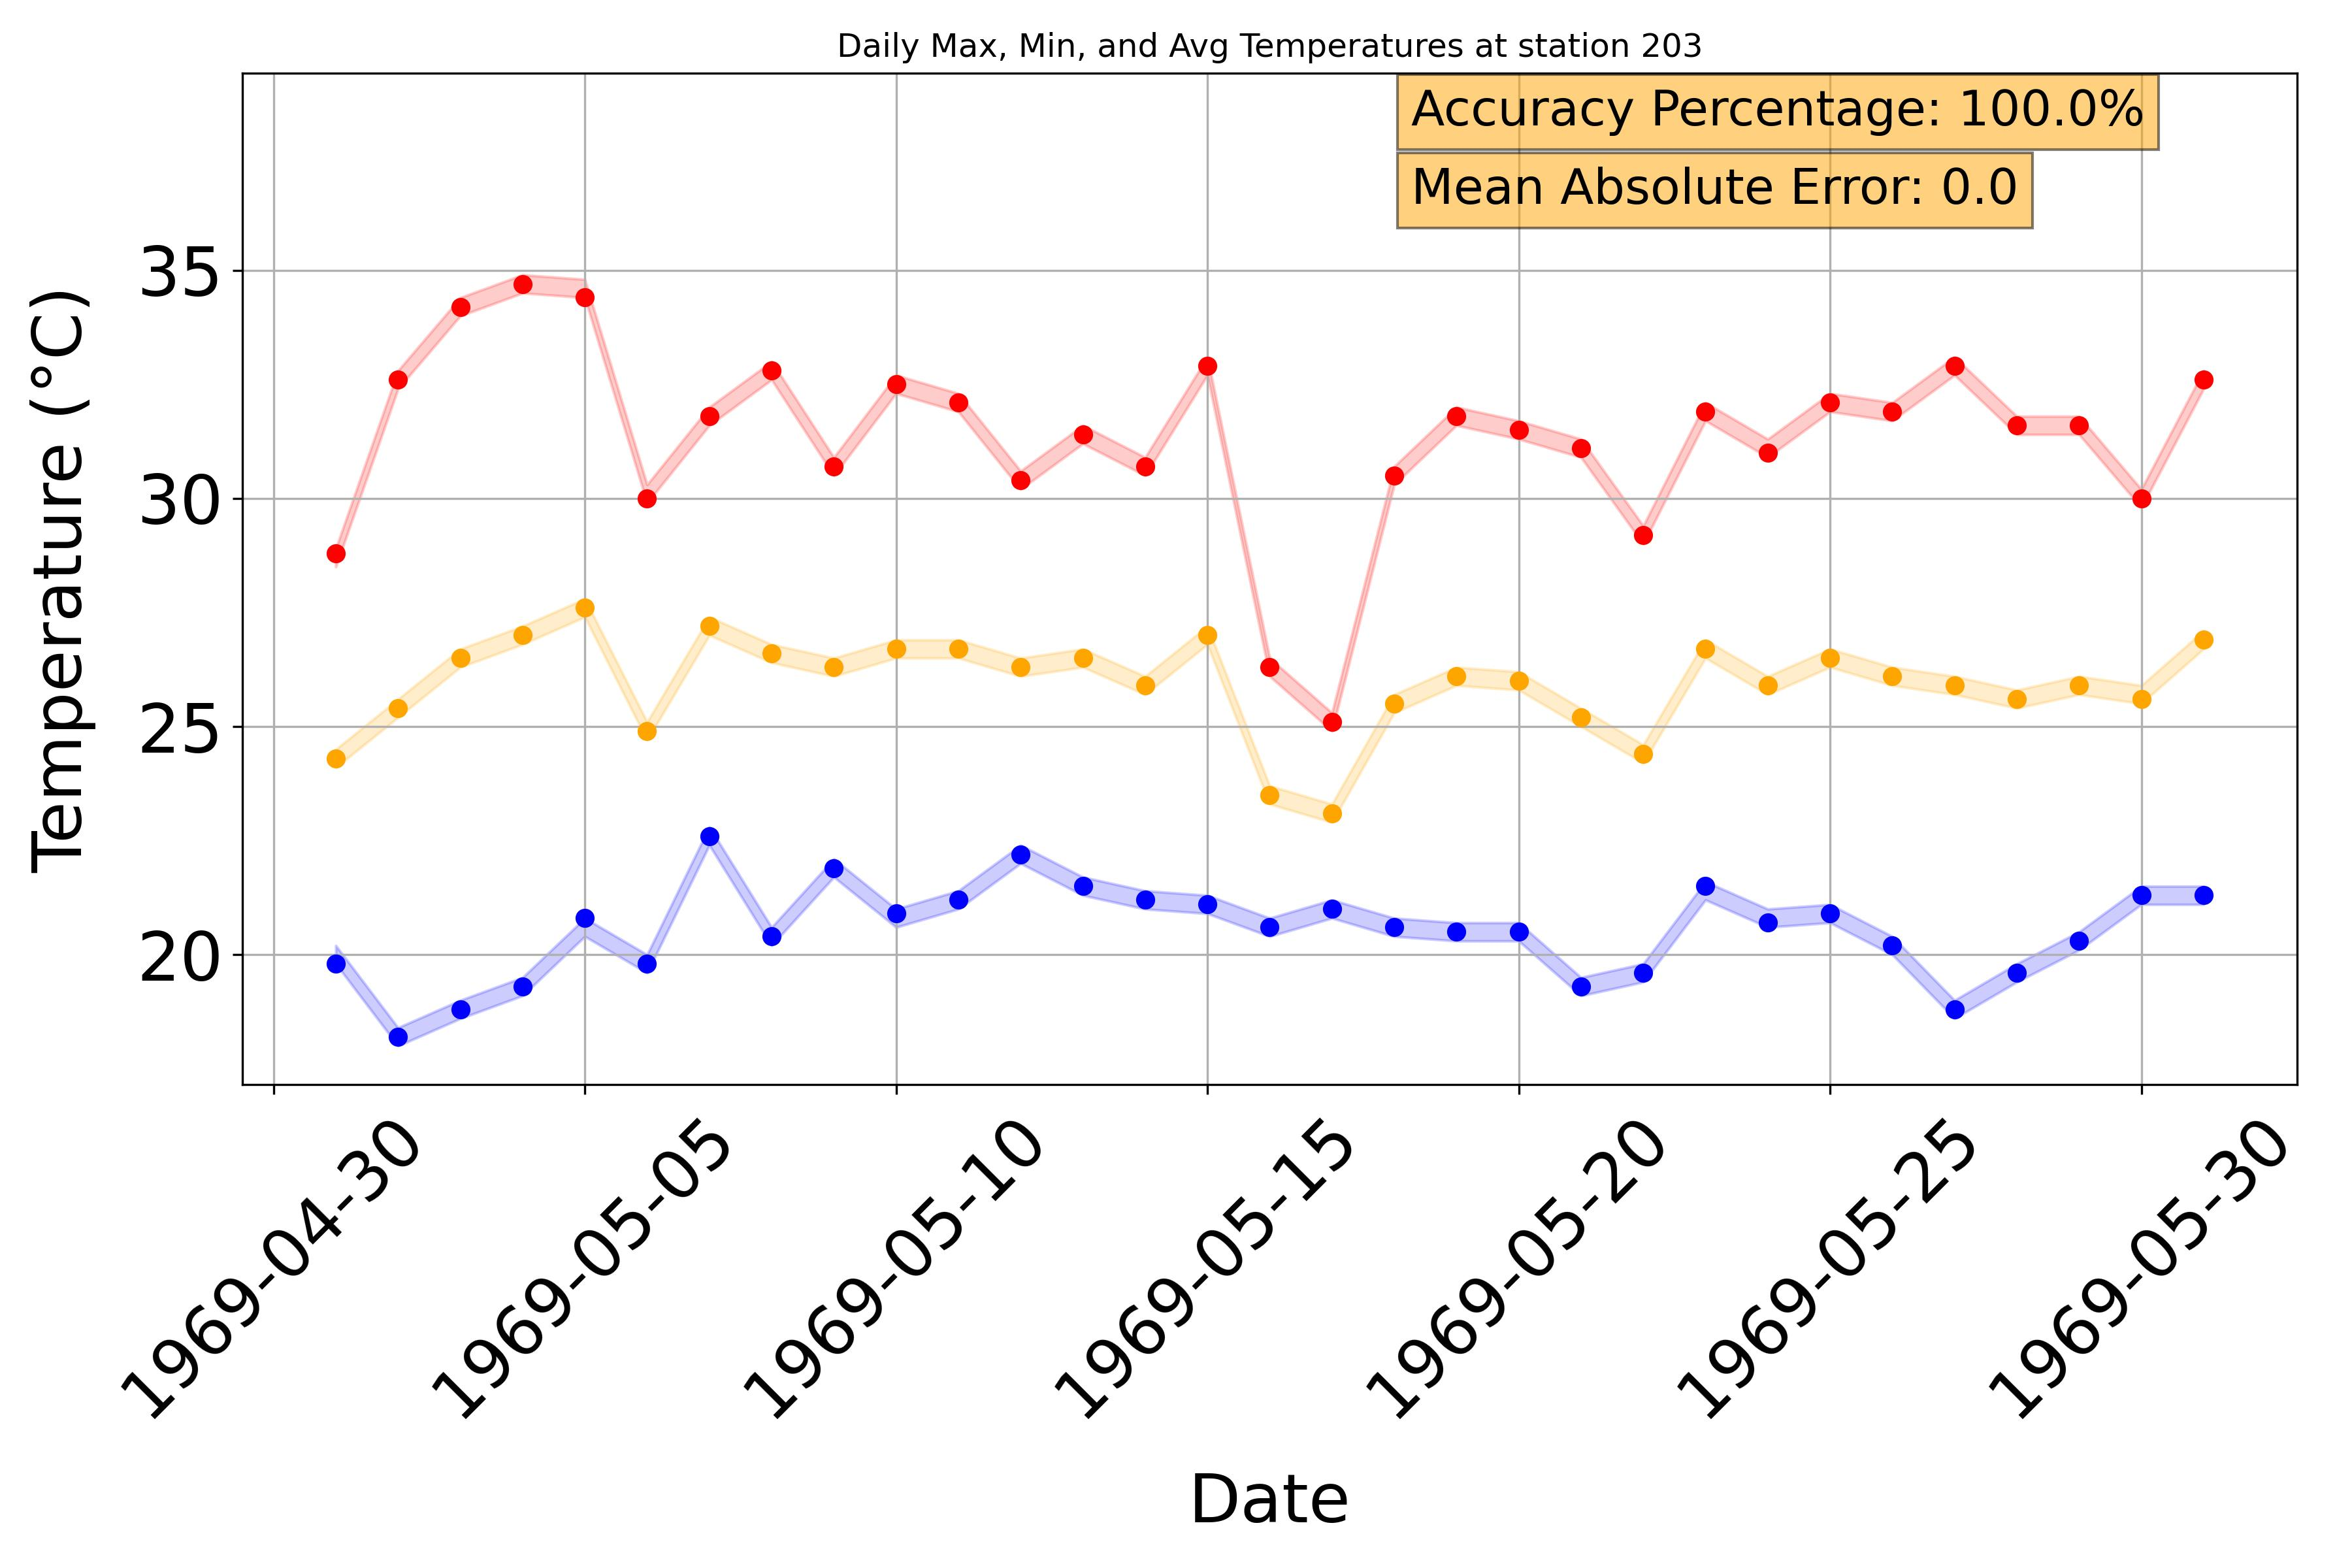

In [22]:
from IPython.display import Image, display

# Display comparison plot 1 from validation
img_path = "results/03_validation_transcibed_data/203/temperature_comparison_plot_203_196905_SF.JPG_post_QA_QC.jpg"
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Validation plot not found.")

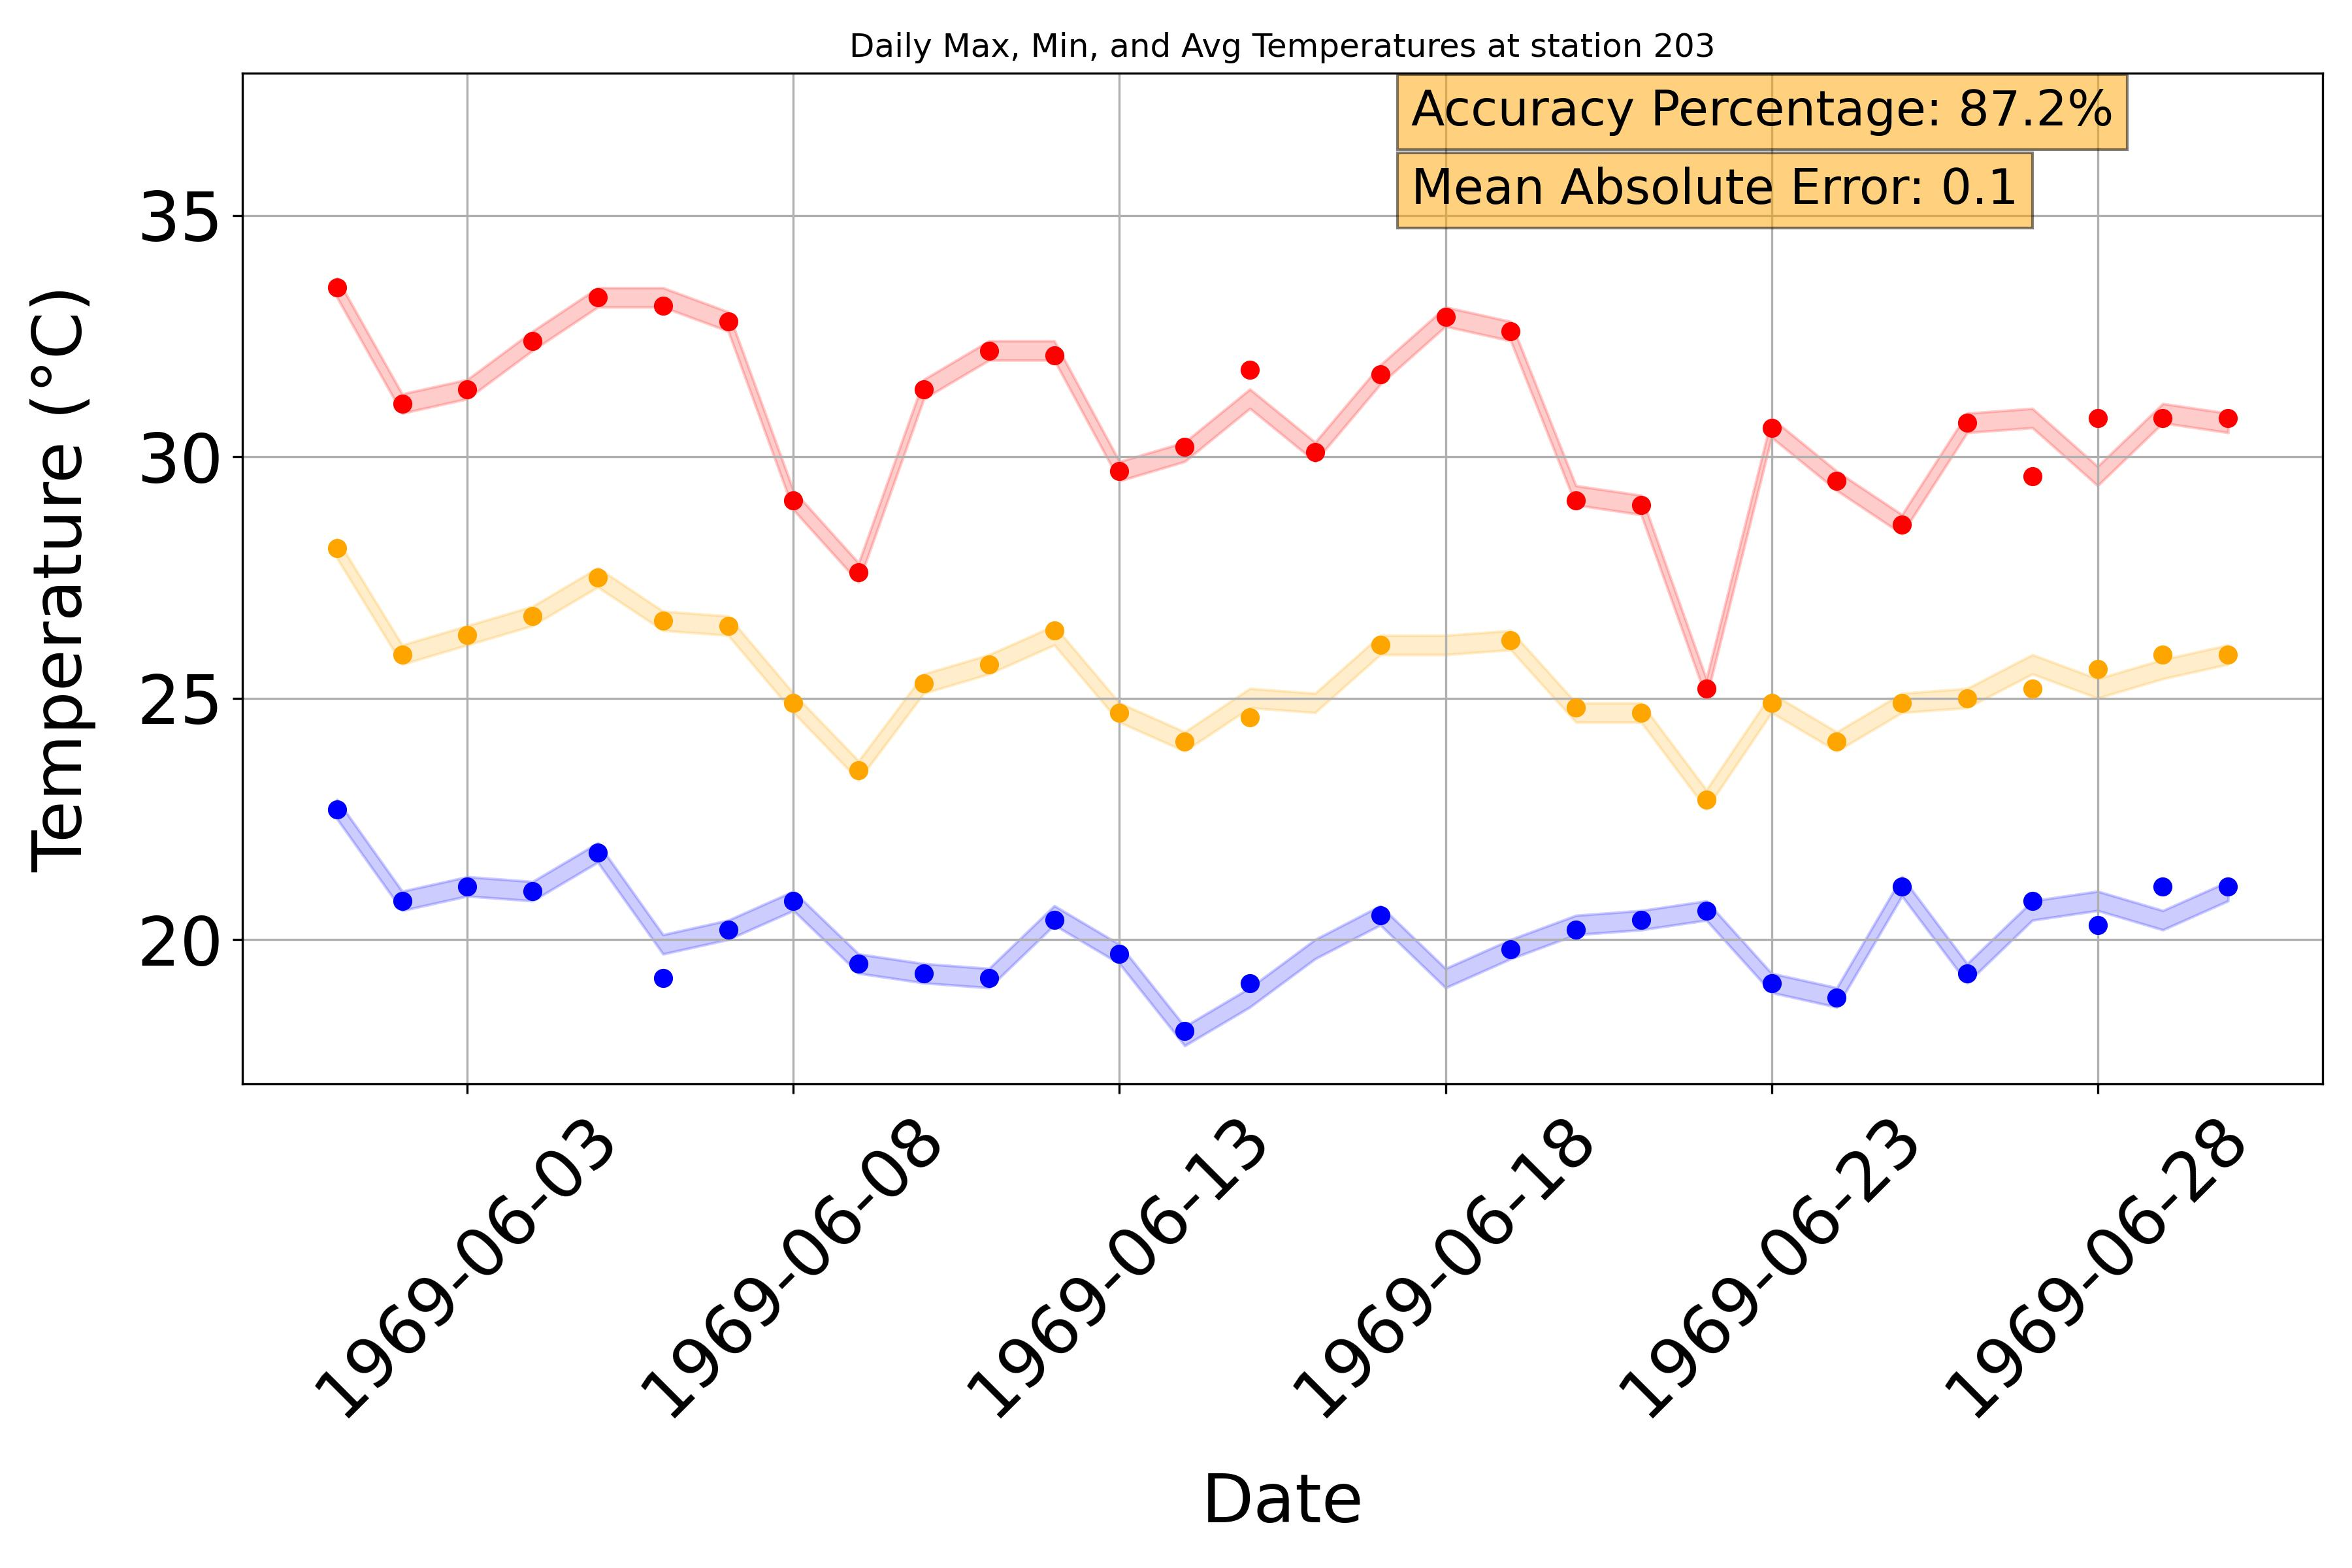

In [23]:
# Display comparison plot 2 from validation
img_path = "results/03_validation_transcibed_data/203/temperature_comparison_plot_203_196906_SF.JPG_post_QA_QC.jpg"
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Validation plot not found.")